In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import xgboost as xgb

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score
import pandas as pd

In [22]:
import sys 
sys.path.append('../')
from ft_engineering import preprocesar_datos

def build_model(model, X_train, y_train):
    """Entrena  el modelo y retorna la instancia ajustada"""
    print(f"Entrenando {model.__class__.__name__}...")
    model.fit(X_train, y_train)
    print('Entrenamiento finalizado')
    return model

def summarize_classification(y_test, y_pred):
    """Genera la tabla resumen y el gráfico de matriz de confusión"""
    print('***Tabla Resumen de Evaluación***')
    print(classification_report(y_test, y_pred))

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title('Matriz de confusión')
    plt.ylabel('Valor real  (y_test)')
    plt.xlabel('Predicción (y_pred)')
    plt.show()

In [23]:

# 1. Cargar datos (corregido de f a df)
df = pd.read_excel('../data/Base_de_datos.xlsx')

# 2. Limpieza igual que en el EDA
columnas_a_borrar = [
    'tipo_credito', 'huella_consulta', 'saldo_mora_codeudor', 
    'puntaje_datacredito', 'tendencia_ingresos', 'saldo_mora', 
    'saldo_total', 'saldo_principal', 'puntaje'
]
df = df.drop(columns=columnas_a_borrar, errors='ignore')

# 3. Separar Features (X) y Target (y)
X = df.drop(columns=['Pago_atiempo'])
y = df['Pago_atiempo']

# 4. Identificar columnas por tipo para transformar
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = ['tipo_laboral']
ord_cols = []

# 5. DIVIDIR LOS DATOS PRIMERO (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Aplicar el pipeline SOLO al set de entrenamiento (fit_transform)
df_train_limpio, preprocessor = preprocesar_datos(X_train, num_cols, cat_cols, ord_cols)

# 7. Aplicar las mismas reglas al set de prueba (transform)
X_test_transformado = preprocessor.transform(X_test)
df_test_limpio = pd.DataFrame(X_test_transformado, columns=preprocessor.get_feature_names_out(), index=X_test.index)

# 8. Guardar los archivos resultantes para el Dashboard de Streamlit
df_train_limpio.to_csv("../data/entrenamiento_limpio.csv", index=False)
df_test_limpio.to_csv("../data/evaluacion_limpia.csv", index=False)


Peso asignado a la clase minoritaria: 0.05
Entrenando XGBClassifier...
Entrenamiento finalizado
***Tabla Resumen de Evaluación***
              precision    recall  f1-score   support

           0       0.10      0.17      0.13       104
           1       0.96      0.92      0.94      2049

    accuracy                           0.89      2153
   macro avg       0.53      0.55      0.53      2153
weighted avg       0.92      0.89      0.90      2153



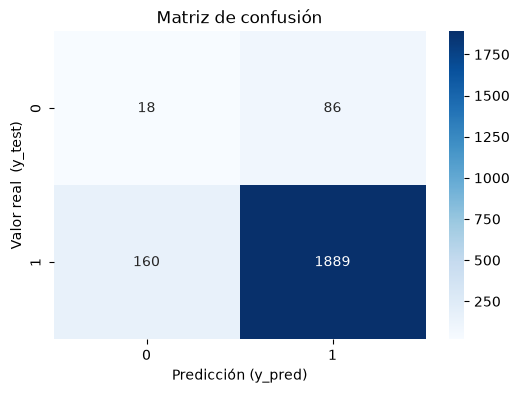

In [24]:
#Balancear el modelo
ratio_desbalance = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
print(f"Peso asignado a la clase minoritaria: {ratio_desbalance:.2f}")


#Instanciar el modelo (XGBoost es excelente para el desbalance de clases)

modelo_xgb = xgb.XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=ratio_desbalance)

#1 Entrenar usando la función
modelo_entrenado = build_model(modelo_xgb, df_train_limpio, y_train)

#2 Generar predicciones
y_pred = modelo_entrenado.predict(df_test_limpio)

#3 Evaluar usando la función
summarize_classification(y_test, y_pred)

In [25]:
#Probaremos otros modelos para medir su desempeño y elegir el mejor

modelos = {
    'XGBoost' : xgb.XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=ratio_desbalance),
    'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'Regresión Logística': LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)
}

metricas = []

In [26]:
for nombre, modelo in modelos.items():
    print(f'Evaluando {nombre}')

    modelo_entrenado = build_model(modelo, df_train_limpio, y_train)
    y_pred = modelo_entrenado.predict(df_test_limpio)

    

    f1 = f1_score(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    metricas.append({'Modelo': nombre, 'F1-Score': f1, 'Accuracy': acc})

df_metricas = pd.DataFrame(metricas)
display(df_metricas)

Evaluando XGBoost
Entrenando XGBClassifier...
Entrenamiento finalizado
Evaluando Random Forest
Entrenando RandomForestClassifier...
Entrenamiento finalizado
Evaluando Regresión Logística
Entrenando LogisticRegression...
Entrenamiento finalizado


,Modelo,F1-Score,Accuracy
0,XGBoost,0.938867,0.885741
1,Random Forest,0.972315,0.946122
2,Regresión Logística,0.722475,0.575012


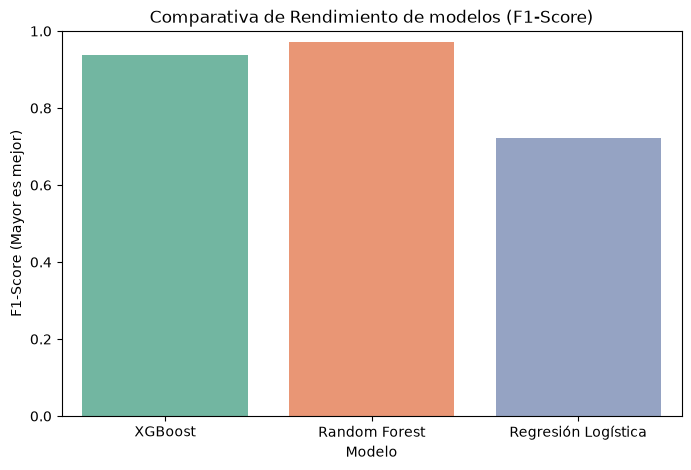

In [27]:
plt.figure(figsize=(8,5))
sns.barplot(data=df_metricas, x='Modelo', y='F1-Score', hue='Modelo', palette='Set2', legend=False)
plt.title('Comparativa de Rendimiento de modelos (F1-Score)')
plt.ylabel('F1-Score (Mayor es mejor)')
plt.ylim(0,1)
plt.show()

Al entrenar los modelos nos dimos cuenta que F1-Score, es perfecto, por lo cual, tenemos una caso de Data Leakage, a continuación vamos a ver cual es la feacture que está provocando esto y la vamos a eliminar del dataset

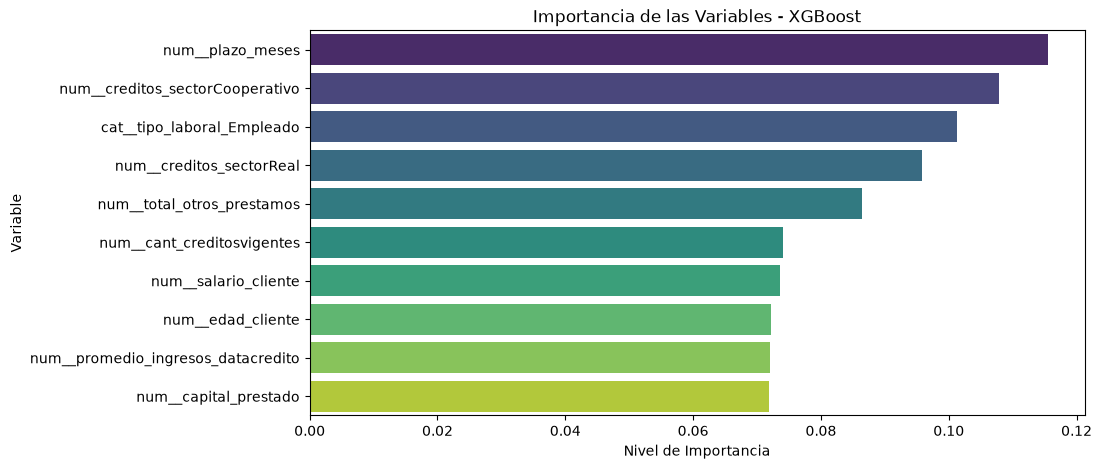

In [29]:
# Extraer importancias específicamente del modelo XGBoost de tu diccionario
modelo_xgb_entrenado = modelos['XGBoost']
importancias = modelo_xgb_entrenado.feature_importances_

# Extraemos los nombres desde el preprocesador, no desde X_train
nombres_columnas = preprocessor.get_feature_names_out()

# Organizar los datos de mayor a menor importancia
df_importancias = pd.DataFrame({'Variable': nombres_columnas, 'Importancia': importancias})
df_importancias = df_importancias.sort_values(by='Importancia', ascending=False)

# Graficar el Top 10
plt.figure(figsize=(10, 5))
sns.barplot(data=df_importancias.head(10), x='Importancia', y='Variable', hue='Variable', palette='viridis', legend=False)
plt.title('Importancia de las Variables - XGBoost')
plt.xlabel('Nivel de Importancia')
plt.show()

La feacture "Puntaje" estaba provocando Data Leakage, al eliminarla, vemos como el gráfico de las variables se encuentra bien equilibrado

Conclusión:
Tras identificar y eliminar la variable puntaje que estaba provocando Data Leakage (fuga de datos), los resultados de nuestros modelos reflejan un escenario de predicción legítimo. Al reevaluar con los datos corregidos, el modelo Random Forest resultó ser el de mejor rendimiento con un F1-Score de 0.97 y un Accuracy de 0.94, seguido de cerca por XGBoost con un F1-Score de 0.94. Ambos algoritmos basados en árboles superaron con amplia ventaja a la Regresión Logística, que cayó a un F1-Score de 0.72.   Aunque obtener un F1-Score de 0.97 sigue siendo excepcionalmente alto para un escenario de riesgo crediticio real (lo que en un entorno productivo nos invitaría a seguir escudriñando la naturaleza de los datos), haber resuelto el problema de Leakage nos garantiza que los modelos ahora sí están aprendiendo los verdaderos patrones complejos de los deudores, en lugar de depender de una variable "espejismo".